Тут я сложил в data/microcap/номер файлы для резистеров разных номиналов. И измеряю отклонение разными методами по этому файлу

In [168]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Signal_char\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [169]:
def get_F_FFT(
    x,
    fs,
    iterations=5,
    zoom_points=100,
    window=True
):
    """
    Итеративный поиск частоты максимальной гармоники
    """
    def local_dft(x, fs, freqs):
        """
        x     : сигнал (1D numpy array)
        fs    : частота дискретизации
        freqs : массив частот (Гц), для которых считаем DFT
        """
        n = np.arange(len(x))
        result = np.zeros(len(freqs), dtype=np.complex128)

        for i, f in enumerate(freqs):
            result[i] = np.sum(x * np.exp(-2j * np.pi * f * n / fs))

        return result
    N = len(x)

    if window:
        x = x * np.hanning(N)

    # --- 1. Грубый FFT ---
    spectrum = np.fft.rfft(x)
    freqs_fft = np.fft.rfftfreq(N, 1 / fs)

    idx_max = np.argmax(np.abs(spectrum))
    f_center = freqs_fft[idx_max]

    # Начальный шаг по частоте
    df = freqs_fft[1] - freqs_fft[0]

    # --- 2. Итеративный зум ---
    for _ in range(iterations):
        freq_grid = np.linspace(
            f_center - df,
            f_center + df,
            zoom_points
        )

        dft_vals = local_dft(x, fs, freq_grid)
        idx_max = np.argmax(np.abs(dft_vals))

        f_center = freq_grid[idx_max]
        df = (freq_grid[1] - freq_grid[0]) * 2

    return f_center

In [170]:
def get_F_2(x, fs):
    def analytic_signal(x):
        N = len(x)
        X = np.fft.fft(x)
    
        H = np.zeros(N)
        if N % 2 == 0:
            H[0] = H[N//2] = 1
            H[1:N//2] = 2
        else:
            H[0] = 1
            H[1:(N+1)//2] = 2
    
        return np.fft.ifft(X * H)

    z = analytic_signal(x)

    phase = np.unwrap(np.angle(z))

    n = np.arange(len(x))
    t = n / fs

    slope, _ = np.polyfit(t, phase, 1)

    return slope / (2 * np.pi)

In [171]:
def frequency_track(method,signal, fs, window, hop):
    freqs = []
    for i in range(0, len(signal) - window, hop):
        freqs.append(
            method(signal[i:i+window], fs) #precise_frequency_estimate(signal[i:i+window], fs)
        )
    return np.array(freqs)

In [172]:
U_path = os.path.join(project_root, "data","real","RTB2004_CHAN1.CSV")
I_path = os.path.join(project_root, "data","real","RTB2004_CHAN2.CSV")

t_real,U_real = md.make_real_data_list(U_path)
t_real,I_real = md.make_real_data_list(I_path)

fs_real=1.0 / np.mean(np.diff(t_real))

F_main_gen = 400e3
duration = 1000 / F_main_gen
fs_gen = F_main_gen * 21

t_gen = np.linspace(0, duration, int(duration * fs_gen))
U_gen =2 * md.generate_sine_random_walk(t_gen,F_main_gen,100,1,45)#+md.generate_sin(t,F_main_gen,0.1)
I_gen =2 * md.generate_sine_random_walk(t_gen,F_main_gen,100,1)#+md.generate_sin(t,F_main_gen,0.1)

In [175]:
F_real=get_F_FFT(U_real,fs_real)
F_gen=get_F_FFT(U_gen,fs_gen)
print("F_real=",F_real," F_gen=",F_gen)
T_real=md.convert_to_counts(t_real,1/F_real) 
T_gen=md.convert_to_counts(t_gen,1/F_gen) 
print("Fs_counts_real=",T_real," Fs_counts_real=",T_gen)

F_real= 444473.82328635384  F_gen= 400012.49976716505
Fs_counts_real= 469  Fs_counts_real= 21


In [176]:
window_int_T=2
F_range_real=frequency_track(get_F_FFT,U_real,fs_real,T_real*window_int_T,int(T_real/2))
F_range_gen=frequency_track(get_F_FFT,U_gen,fs_gen,T_gen*window_int_T,int(T_gen/2))

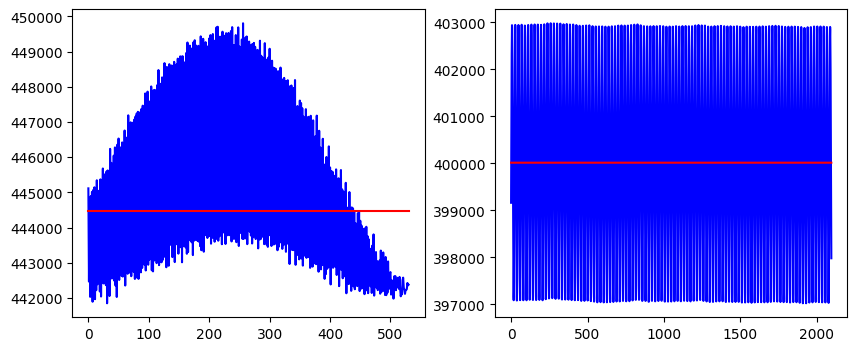

In [177]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(F_range_real, 'b')
ax1.plot(np.full(len(F_range_real), F_real), 'r')
#
ax2.plot(F_range_gen, 'b')
ax2.plot(np.full(len(F_range_gen), F_gen), 'r')

plt.show()

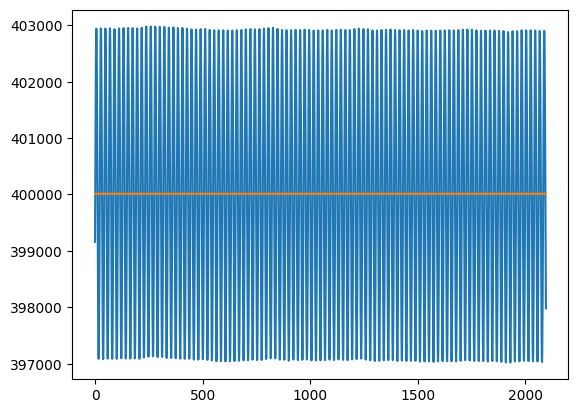

In [178]:
plt.plot(F_range_gen)
plt.plot(np.full(len(F_range_gen), F_gen))

In [183]:
# === Allan deviation ===
def allan_deviation(y, fs):
    tau0 = 1 / fs
    m = np.unique(np.logspace(0, 4, 25).astype(int))
    taus, adev = [], []

    for mi in m:
        n = len(y) // mi - 1
        if n <= 1:
            continue

        y_avg = np.mean(y[:n*mi].reshape(n, mi), axis=1)
        adev.append(np.sqrt(0.5 * np.mean(np.diff(y_avg) ** 2)))
        taus.append(mi * tau0)

    return np.array(taus), np.array(adev)

In [213]:
import scipy.signal as sig

# === полосовой фильтр ===
bw = 0.1 * F_real
b, a = sig.butter(
    4,
    [(F_real - bw) / (fs_real / 2), (F_real + bw) / (fs_real/ 2)],
    btype="band"
)
tf,vf = md.filter_butter_bandpass(t_real,U_real,F_real,0.1*F_real,2)
#vf = sig.filtfilt(b, a, v)
# === аналитический сигнал ===
analytic = signal.hilbert(vf)
phase = np.unwrap(np.angle(analytic))
inst_freq = np.diff(phase) / (2*np.pi) * fs_real
t_if = tf[1:]

# === мгновенная частота ===
inst_freq = np.diff(phase) / (2 * np.pi) * fs_real
t_if = t_real[1:]

# === относительное отклонение частоты ===
df_rel = (inst_freq - F_real) / F_real

print(f"σ(f)/f = {np.std(df_rel):.3e}")

taus, adev = allan_deviation(inst_freq / F_real, fs_real)


σ(f)/f = 8.774e-02


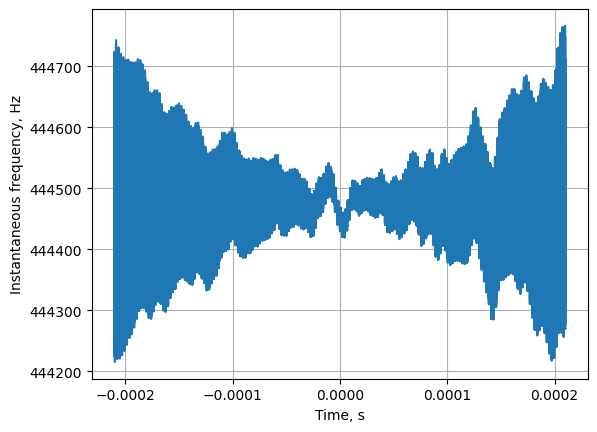

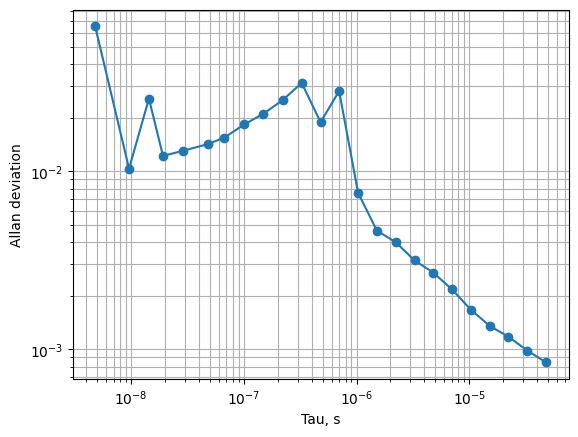

In [214]:
# === графики ===
N = len(inst_freq)
cut = int(0.15 * N)

plt.figure()
plt.plot(t_if[cut:-cut], inst_freq[cut:-cut])
plt.xlabel("Time, s")
plt.ylabel("Instantaneous frequency, Hz")
plt.grid()

plt.figure()
plt.loglog(taus, adev, marker="o")
plt.xlabel("Tau, s")
plt.ylabel("Allan deviation")
plt.grid(True, which="both")

plt.show()

In [215]:
def zero_crossings_interp(time, signal):
    """
    Возвращает массив времен zero-crossing (от - к +)
    с линейной интерполяцией
    """
    zc_times = []
    for i in range(len(signal) - 1):
        if signal[i] < 0 and signal[i + 1] >= 0:
            # линейная интерполяция
            t1, t2 = time[i], time[i + 1]
            y1, y2 = signal[i], signal[i + 1]
            t_zero = t1 - y1 * (t2 - t1) / (y2 - y1)
            zc_times.append(t_zero)
    return np.array(zc_times)

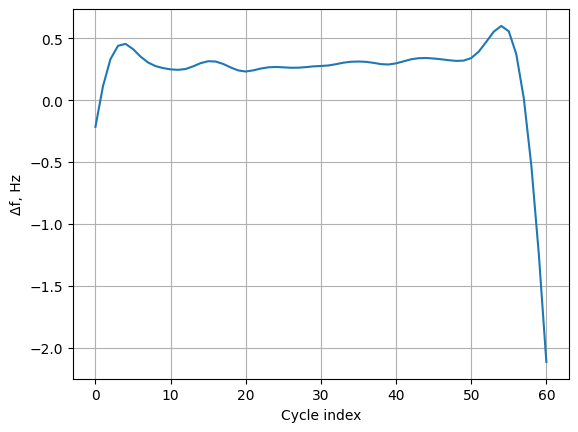

RMS Δf = 0.8921216196977562 Hz


In [223]:
zeros=zero_crossings_interp(tf,vf)
F_range=[]
for i in range(0,len(zeros)-1,1):
    time_shift=zeros[i+1]-zeros[i]
    F_range.append(1/time_shift)

# zero crossings уже посчитаны
N = 20   # усреднение по 20 периодам


n=10
T = zeros[n*N:] - zeros[:-n*N]
F = N / T

border = int(0.05 * len(F))

plt.figure()
plt.plot(F[border:-border] - np.mean(F))
plt.xlabel("Cycle index")
plt.ylabel("Δf, Hz")
plt.grid()
plt.show()

print("RMS Δf =", np.std(F), "Hz")


In [219]:
print(0.01*1e-6*F_real)

0.0044447382328635385
